In [1]:
# %% Inspect HGD .mat v7.3 con h5py
import os
import glob
import h5py

# Configura il path
dataset_dir = '/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/dataset'
mat_files   = sorted(glob.glob(os.path.join(dataset_dir, '**', '*.mat'), recursive=True))
print(f"Trovati {len(mat_files)} file .mat (v7.3) in {dataset_dir}\n")

def inspect_hgdm(file_path):
    print("\n" + "="*80)
    print(f"File: {os.path.basename(file_path)}")
    with h5py.File(file_path, 'r') as f:
        # Chiavi di primo livello
        keys = list(f.keys())
        print("Top‑level keys:", keys)
        for key in keys:
            ds = f[key]
            # Dataset HDF5 o group?
            if isinstance(ds, h5py.Dataset):
                print(f" - {key}: Dataset, shape={ds.shape}, dtype={ds.dtype}")
            else:
                # group: esplodo un livello
                sub = list(ds.keys())
                print(f" - {key}: Group, subkeys={sub}")
        # Se X esiste, provalo
        if 'X' in f:
            X = f['X']
            print(f"   -> X: shape={X.shape}, dtype={X.dtype}")
        if 'y' in f:
            y = f['y']
            print(f"   -> y: shape={f['y'].shape}, dtype={f['y'].dtype}")
        if 'fs' in f:
            fs = f['fs'][()]
            print(f"   -> fs: {fs}")
        if 'channels' in f:
            ch = f['channels'][()]
            # spesso viene salvato come array di int riferimenti a char
            try:
                chans = [''.join(chr(c) for c in arr).strip() for arr in ch.T]
                print(f"   -> channels: {chans}")
            except:
                print(f"   -> channels raw: {ch}")

# Esegui inspection su tutti
for m in mat_files:
    inspect_hgdm(m)


Trovati 28 file .mat (v7.3) in /Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/dataset


File: 1.mat
Top‑level keys: ['ch1', 'ch10', 'ch100', 'ch101', 'ch102', 'ch103', 'ch104', 'ch105', 'ch106', 'ch107', 'ch108', 'ch109', 'ch11', 'ch110', 'ch111', 'ch112', 'ch113', 'ch114', 'ch115', 'ch116', 'ch117', 'ch118', 'ch119', 'ch12', 'ch120', 'ch121', 'ch122', 'ch123', 'ch124', 'ch125', 'ch126', 'ch127', 'ch128', 'ch129', 'ch13', 'ch130', 'ch131', 'ch132', 'ch133', 'ch14', 'ch15', 'ch16', 'ch17', 'ch18', 'ch19', 'ch2', 'ch20', 'ch21', 'ch22', 'ch23', 'ch24', 'ch25', 'ch26', 'ch27', 'ch28', 'ch29', 'ch3', 'ch30', 'ch31', 'ch32', 'ch33', 'ch34', 'ch35', 'ch36', 'ch37', 'ch38', 'ch39', 'ch4', 'ch40', 'ch41', 'ch42', 'ch43', 'ch44', 'ch45', 'ch46', 'ch47', 'ch48', 'ch49', 'ch5', 'ch50', 'ch51', 'ch52', 'ch53', 'ch54', 'ch55', 'ch56', 'ch57', 'ch58', 'ch59', 'ch6', 'ch60', 'ch61', 'ch62', 'ch63', 'ch64', 'ch65', 'ch66', 'ch67', 'ch68', 'ch69', 'ch7', 'ch70', 'ch71', 'ch72', 'ch73', 'ch74', 'ch75', 

Creating RawArray with float64 data, n_channels=128, n_times=610820
    Range : 0 ... 610819 =      0.000 ...  1221.638 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Dati grezzi CST_raw_mne: (129, 610820)
RAW:  <Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, Fpz, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, M1, T7, ...
 chs: 128 misc, 1 Stimulus
 custom_ref_applied: False
 dig: 0 items
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 129
 projs: []
 sfreq: 500.0 Hz
>
ANNOTAIONS: <Annotations | 0 segments>
Valori unici nel canale di Stimulus: [0. 2. 4. 6. 8.]
Tempo di un campione: 0.002
160 events found on stim channel STI 014
Event IDs: [2 4 6 8]
Numero di eventi: 160
Durate degli eventi: [ 3960  3970  3575  3690  3780  3775  3690  3575  3545  3900  3645  3905
  3550  3890  3695  3680  3560  3555  3715  3845  3760  3580  3575  3925
  3960  3900  3620  3575  3570  3955  3975  3660  3760  3625  3540  3765
  3595  3715

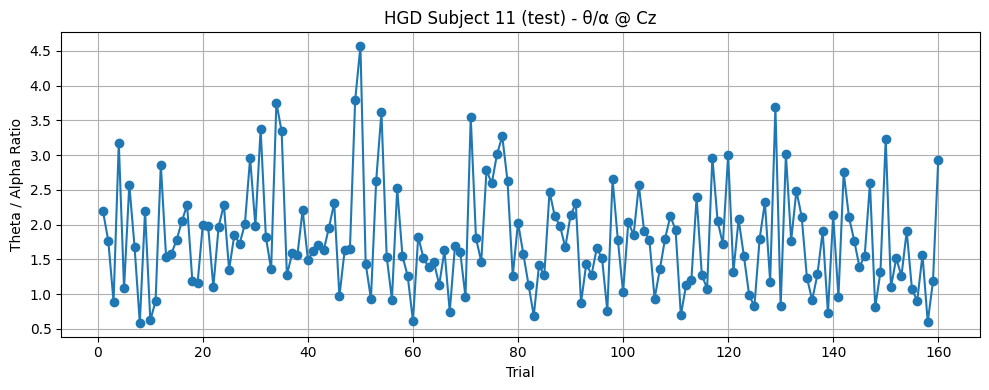

,trial,true_label,theta_alpha
0,1,3,2.189681
1,2,0,1.765425
2,3,2,0.893445
3,4,1,3.174782
4,5,2,1.082624


In [2]:
# %% MWL (θ/α) – HGD  ♦  soggetto singolo (split test)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

# ---- 1) Parametri da personalizzare -----------------
root_dir      = '/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/dataset'  # cartella con train/ e test/
subject       = 11          # numero file: 'test/1.mat'
training      = False      # False = test , True = train
channel_name  = 'Cz'       # uno dei canali mantenuti nel tuo preprocess
tmin, tmax    = 0.0, 4.0   # finestra (s) all’interno del trial (-0.5…4.5)
theta_band    = (4, 7)
alpha_band    = (8, 12)
# -----------------------------------------------------

# ---- 2) Carica i dati con la TUA funzione di preprocess ---------------
# %% (da inserire in cima al notebook, prima dell'import)
import sys, os

# path assoluto o relativo fino alla cartella che contiene preprocess_HGD.py
proj_root = os.path.abspath("/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD")          # <-- esempio: due livelli sopra
#  oppure:  proj_root = "/Users/giuseppebonomo/Progetto/preprocess"

if proj_root not in sys.path:
    sys.path.append(proj_root)                # ora Python cercherà anche qui

from preprocess_HGD import load_HGD_data      # ← finalmente l’import

from preprocess_HGD import load_HGD_data
X, y = load_HGD_data(root_dir + '/', subject, training)     # X: (trials,ch,samples)
fs   = 250.0                                                # fissato nel preprocess

# ---- 3) Trova indice del canale desiderato ----------------------------
#  ordine dei canali dipende dal pick nella tua load_HGD_data
pick_channels = ['C3', 'C4', 'C2', 'Cz']   # ← aggiorna se diverso
if channel_name not in pick_channels:
    raise ValueError(f"{channel_name} non trovato in {pick_channels}")
ch_idx = pick_channels.index(channel_name)

# ---- 4) Calcola rapporto θ/α per ogni trial ---------------------------
start = int((tmin + 0.5) * fs)   # +0.5 s: trial include ‑0.5…4.5 s
end   = int((tmax + 0.5) * fs)
end   = min(end, X.shape[2])

ratios = []
for sig in X[:, ch_idx, start:end]:
    f, Pxx = welch(sig, fs=fs, nperseg=int(fs*2))
    th = np.trapz(Pxx[(f>=theta_band[0]) & (f<=theta_band[1])],
                  f[(f>=theta_band[0]) & (f<=theta_band[1])])
    al = np.trapz(Pxx[(f>=alpha_band[0]) & (f<=alpha_band[1])],
                  f[(f>=alpha_band[0]) & (f<=alpha_band[1])])
    ratios.append(th / (al + 1e-6))

# ---- 5) DataFrame e salvataggio CSV -----------------------------------
df = pd.DataFrame({
    'trial':       np.arange(1, len(ratios)+1),
    'true_label':  y.astype(int),       # 0‑based come nel tuo preprocess
    'theta_alpha': ratios
})
csv_out = f'hgd_sub{subject}_{"train" if training else "test"}_mwl.csv'
df.to_csv(csv_out, index=False)
print(f"✅ CSV salvato in: {csv_out}")

# ---- 6) Grafico --------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(df['trial'], df['theta_alpha'], marker='o')
plt.title(f'HGD Subject {subject} ({"train" if training else "test"}) - θ/α @ {channel_name}')
plt.xlabel('Trial')
plt.ylabel('Theta / Alpha Ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- 7) Anteprima ------------------------------------------------------
df.head()


In [3]:
import pandas as pd
df = pd.read_csv('hgd_sub11_test_mwl.csv')
print(df[['theta_alpha']].describe())
# group by class label (0=left, 1=right, 2=foot, 3=tongue)
print(df.groupby('true_label')['theta_alpha'].agg(['mean','median','std','count']))


       theta_alpha
count   160.000000
mean      1.791313
std       0.763479
min       0.586350
25%       1.262420
50%       1.667845
75%       2.132008
max       4.568544
                mean    median       std  count
true_label                                     
0           1.904726  1.768617  0.745698     40
1           1.980231  1.878151  0.739431     40
2           1.380185  1.197741  0.680372     40
3           1.900111  1.737432  0.758560     40


✅ CSV salvato in: /Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S11/hgd_sub11_results.csv
✅ Grafico salvato in: /Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S11/hgd_sub11_plot.png


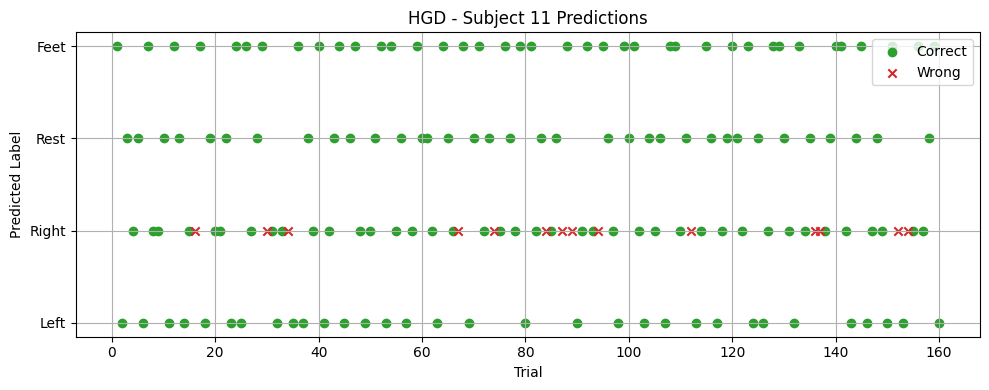

In [4]:
# %%  Analisi predizioni HGD (scalabile per soggetto)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_hgd_preds(data_dir, subject,
                      prefix='HGD_sub',           # prefisso file
                      out_prefix='hgd_sub',       # prefisso output
                      yticks_labels=('Left','Right','Rest','Feet')):
    """
    data_dir : cartella con i .npy generati dal tuo script di inferenza
    subject  : int  -> genera <prefix><N>_true.npy  e  <prefix><N>_pred.npy
    """
    # ------- 1) Costruisci automaticamente i nomi -----------
    true_path = os.path.join(data_dir, f"{prefix}{subject}_true.npy")
    pred_path = os.path.join(data_dir, f"{prefix}{subject}_cmds.npy")

    if not (os.path.exists(true_path) and os.path.exists(pred_path)):
        raise FileNotFoundError("File .npy non trovati:"
                                f"\n  {true_path}\n  {pred_path}")

    # ------- 2) Carica ----------
    y_true = np.load(true_path)
    y_pred = np.load(pred_path)
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch: {y_true.shape} vs {y_pred.shape}")

    n_trials = len(y_true)

    # ------- 3) DataFrame & CSV ----------
    df = pd.DataFrame({'trial': np.arange(1, n_trials+1),
                       'true_label': y_true,
                       'pred_label': y_pred})

    csv_out = os.path.join(directory, f"{out_prefix}{subject}_results.csv")
    df.to_csv(csv_out, index=False)
    print(f"✅ CSV salvato in: {csv_out}")

    # ------- 4) Plot ----------
    correct = y_true == y_pred
    plt.figure(figsize=(10,4))
    plt.scatter(df['trial'][correct], y_pred[correct],
                c='tab:green', marker='o', label='Correct')
    plt.scatter(df['trial'][~correct], y_pred[~correct],
                c='tab:red', marker='x', label='Wrong')

    plt.title(f"HGD - Subject {subject} Predictions")
    plt.xlabel("Trial")
    plt.ylabel("Predicted Label")
    plt.yticks(range(len(yticks_labels)), yticks_labels)
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()

    png_out = os.path.join(directory, f"{out_prefix}{subject}_plot.png")
    plt.savefig(png_out, dpi=150)
    print(f"✅ Grafico salvato in: {png_out}")
    plt.show()

    return df   # opzionale, così puoi ri‑utilizzare

# %% --------- ESEMPIO DI UTILIZZO -------------
subject  = 11 
data_dir = "/Users/giuseppebonomo/Desktop/RatioWaveNet/CASPER_RatioWaveNet/commands/HGD"
directory = f"/Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S{subject}"


df_sub1 = analyze_hgd_preds(data_dir, subject)


✅ CSV combinato salvato in: hgd_sub11_combined.csv


/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_21535/2807832128.py:37: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  sc_wrong = plt.scatter(tr[~corr], pr[~corr],


✅ Grafico salvato in: hgd_sub11_combined_plot.png


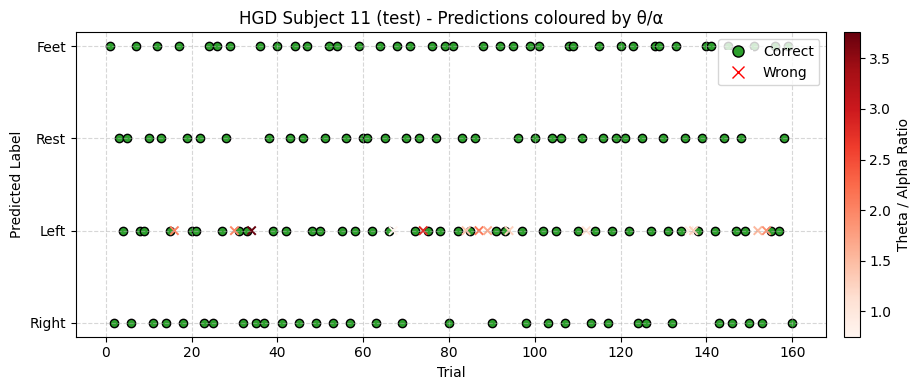

In [5]:
# %% Merge + plot con color‑bar rossa e marker X per i Wrong  (HGD)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ------------ PARAMETRI ------------
subject      = 11
split        = 'test'
results_csv  = f"hgd_sub{subject}_results.csv"
mwl_csv      = f"hgd_sub{subject}_{split}_mwl.csv"
out_combined = f"hgd_sub{subject}_combined.csv"
out_png      = f"hgd_sub{subject}_combined_plot.png"
# -----------------------------------

# 1) merge
df_pred = pd.read_csv(results_csv)
df_mwl  = pd.read_csv(mwl_csv)
combined = pd.merge(df_pred, df_mwl[['trial','theta_alpha']], on='trial')
combined.to_csv(out_combined, index=False)
print(f"✅ CSV combinato salvato in: {out_combined}")

# 2) maschere
corr = combined['true_label'] == combined['pred_label']
tr   = combined['trial']
pr   = combined['pred_label']
rat  = combined['theta_alpha']

plt.figure(figsize=(10,4))

# 3) scatter Correct (cerchi verdi, colore fisso)
plt.scatter(tr[corr], pr[corr],
            c='tab:green', marker='o', edgecolor='k', label='Correct')

# 4) scatter Wrong (X rosse, colore da colormap Reds)
sc_wrong = plt.scatter(tr[~corr], pr[~corr],
                       c=rat[~corr], cmap='Reds',
                       marker='x', edgecolor='k', linewidths=1.4,
                       label='Wrong')

# 5) color‑bar ROSSA (presa da sc_wrong)
cbar = plt.colorbar(sc_wrong, pad=0.02)
cbar.set_label('Theta / Alpha Ratio')

plt.title(f"HGD Subject {subject} ({split}) - Predictions coloured by θ/α")
plt.xlabel('Trial')
plt.ylabel('Predicted Label')
plt.yticks([0,1,2,3], ['Right','Left','Rest','Feet'])
plt.grid(True, linestyle='--', alpha=0.5)

# legenda manuale con i due marker
legend_elems = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='tab:green', markeredgecolor='k',
           markersize=8, label='Correct'),
    Line2D([0],[0], marker='x', color='w',
           markeredgecolor='red', markersize=8, linewidth=1.4,
           label='Wrong')
]
plt.legend(handles=legend_elems, loc='upper right')
plt.tight_layout()

plt.savefig(out_png, dpi=150)
print(f"✅ Grafico salvato in: {out_png}")
plt.show()


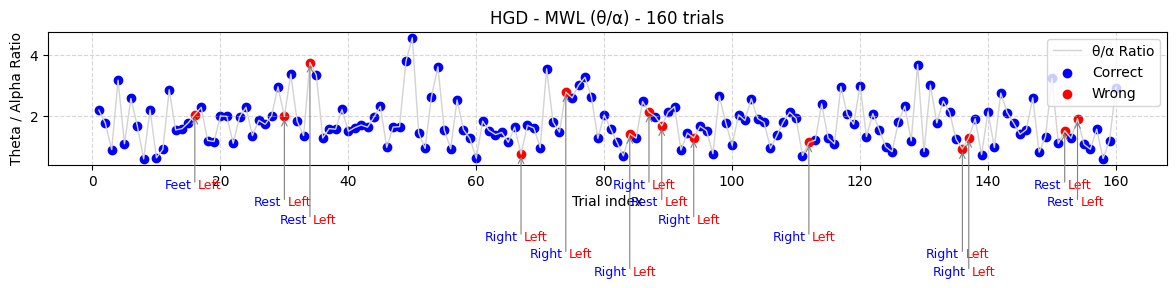

✅ Grafico salvato in: /Users/giuseppebonomo/Desktop/RatioWaveNet/HGD/mental_work_load/S11/hgd_sub11_mwl_plot.png


<Figure size 640x480 with 0 Axes>

In [6]:
# %%  Frecce esplicative su θ/α – HGD

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Assumo che tu abbia già costruito `combined_df` con:
#   trial, true_label, pred_label, theta_alpha
# ------------------------------------------------------------------

# ---------- 1) Dati di base -----------------
trials = combined['trial'].values
ratios = combined['theta_alpha'].values
true   = combined['true_label'].values
preds  = combined['pred_label'].values

wrong_mask   = preds != true
wrong_trials = trials[wrong_mask]
wrong_ratios = ratios[wrong_mask]
true_wrong   = true[wrong_mask]
pred_wrong   = preds[wrong_mask]

# mappa class‑id → stringa  (HGD: 0=Right,1=Left,2=Rest,3=Feet)
class_names = {0:'Right', 1:'Left', 2:'Rest', 3:'Feet'}

n_trials = trials.max()

fig, ax = plt.subplots(figsize=(12, 5))

# ---------- 2) Trace MWL + scatter correct / wrong ---------------
ax.plot(trials, ratios, color='lightgray', lw=1, label='θ/α Ratio')
ax.scatter(trials[~wrong_mask], ratios[~wrong_mask],
           c='blue', marker='o', label='Correct')
ax.scatter(wrong_trials, wrong_ratios,
           c='red', marker='o', label='Wrong')

# ---------- 3) Offset livelli per le etichette (a ciclo) ----------
levels = [-0.15, -0.28, -0.41, -0.54, -0.67, -0.80]  # frazione dell’asse y
ymin, ymax = ax.get_ylim()
yrange = ymax - ymin

for idx, (t, r, lbl_t, lbl_p) in enumerate(zip(
        wrong_trials, wrong_ratios, true_wrong, pred_wrong)):
    y_frac = levels[idx % len(levels)]          # ruota i livelli
    y_text = ymin + y_frac * yrange            # coord. in dati

    # freccia verticale
    ax.annotate('', xy=(t, r), xycoords='data',
                xytext=(t, y_text), textcoords='data',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

    # True label (blu) a sinistra
    ax.text(t - 0.5, y_text, class_names[lbl_t],
            color='blue', fontsize=9, ha='right', va='center')
    # Pred label (rosso) a destra
    ax.text(t + 0.5, y_text, class_names[lbl_p],
            color='red', fontsize=9, ha='left',  va='center')

# ---------- 4) Finitura grafico -----------------
ax.set_title(f"HGD - MWL (θ/α) - {n_trials} trials")
ax.set_xlabel("Trial index")
ax.set_ylabel("Theta / Alpha Ratio")
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Salvo il grafico
png_out = os.path.join(directory, f"hgd_sub{subject}_mwl_plot.png")
plt.savefig(png_out, dpi=150)
print(f"✅ Grafico salvato in: {png_out}")
